# Case Study 1

This case study explores explicit time-stepping schemes on the Lorenz ‘63
system and asks you to build and validate a reusable numerical solver. The main objective is to develop a
numerical model.

* Develop a numerical model of a chaotic system and verify convergence.
* Explore some properties of Lorenz system.
* Demonstrate the outcome of scientific inquiries about numerical solution of differential equations.

Consider the Lorenz System:

$$\frac{dx}{dt} = \sigma(y-x), \frac{dy}{dt} = x(\rho-z)-y, \frac{dx}{dt} = xy - \beta z$$


The parameters are $(\sigma, \rho, \beta)$ = (10, 28, 8/3)

In [34]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt

### Lorenz System 

In [35]:
# Lorenz System 
def lorenz(t, state, sigma=10, rho=28, beta=8/3):
    """
    Args:
        t: time
        state: [x, y, z] current state
        sigma, rho, beta: Lorenz parameters
        
    Returns: 
        [dx/dt, dy/dt, dz/dt]
    """
    
    x, y, z = state
    
    dx_dt = sigma*(y - x)
    dy_dt = x*(rho - z)
    dz_dt = x*y - beta*z
    
    return np.array([dx_dt, dy_dt, dz_dt])

### Forward Euler method

$$y_{n+1} = y_n + dt * f(t_n, y_n)$$

In [36]:
# Forward Euler method
def euler(f, y0, t_span, dt):
    """
    Args:
        f: function that dy/dt given (t, y)
        y0: initial condition [array]
        t_span: (t_start, t_end)
        dt: time step
        
    Returns: 
        t: time points (array)
        y: solution values (array)
    """
    
    t_start, t_end = t_span
    t = np.arange(t_start, t_end + dt, dt)
    n_steps = len(t)
    
    # solution array
    y = np.zeros((n_steps, len(y0)))
    y[0] = y0
    
    # Time stepping
    for i in range(n_steps - 1):
        y[i+1] = y[i] + dt * f(t[i], y[i])
        
    return t, y
    

### Runge-Kutta method


In [37]:
# Runge-Kutta method
def rk4(f, y0, t_span, dt):
    """
        Args:
        f: function that dy/dt given (t, y)
        y0: initial condition [array]
        t_span: (t_start, t_end)
        dt: time step
        
    Returns: 
        t: time points (array)
        y: solution values (array)
    """
    
    t_start, t_end = t_span
    t = np.arange(t_start, t_end + dt, dt)
    n_steps = len(t)
    
    # solution array
    y = np.zeros((n_steps, len(y0)))
    y[0] = y0
    
    # Time stepping with RK4
    for i in range(n_steps - 1):
        k1 = f(t[i], y[i])
        k2 = f(t[i] + 0.5*dt, y[i] + 0.5*dt*k1)
        k3 = f(t[i] + 0.5*dt, y[i] + 0.5*dt*k2)
        k4 = f(t[i] + dt, y[i] + dt*k3)
        
        y[i+1] = y[i] + (k1 + 2*k2 + 2*k3 + k4) * (dt/6)
        
    return t, y

### Solving Lorenz system

In [47]:
y0 = np.array([1., 1., 1.]) # Initial condition

t_span = (0, 100)
dt = 0.02 # time step

t_euler, y_euler = euler(lorenz, y0, t_span, dt)
t_rk4, y_rk4 = euler(lorenz, y0, t_span, dt)

print(f"Euler: computed {len(t_euler)} time steps")
print(f"RK4: computed {len(t_rk4)} time steps")



Euler: computed 5001 time steps
RK4: computed 5001 time steps


In [48]:
y_euler

array([[ 1.        ,  1.        ,  1.        ],
       [ 1.        ,  1.54      ,  0.96666667],
       [ 1.108     ,  2.08066667,  0.94591111],
       ...,
       [ 5.91143392, -2.73990482, 33.56284368],
       [ 4.18116617, -3.39759247, 31.44889002],
       [ 2.66541444, -3.68600012, 29.48749792]], shape=(5001, 3))

In [49]:
y_rk4

array([[ 1.        ,  1.        ,  1.        ],
       [ 1.        ,  1.54      ,  0.96666667],
       [ 1.108     ,  2.08066667,  0.94591111],
       ...,
       [ 5.91143392, -2.73990482, 33.56284368],
       [ 4.18116617, -3.39759247, 31.44889002],
       [ 2.66541444, -3.68600012, 29.48749792]], shape=(5001, 3))

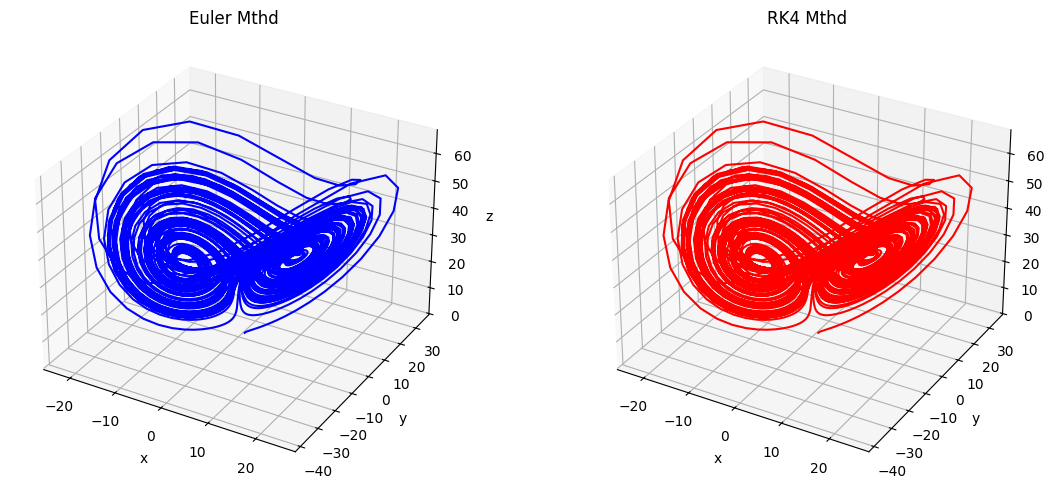

In [50]:
fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(121, projection="3d")
ax1.plot(y_euler[:, 0], y_euler[:, 1], y_euler[:, 2], "b-")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")
ax1.set_title("Euler Mthd")

ax1 = fig.add_subplot(122, projection="3d")
ax1.plot(y_rk4[:, 0], y_rk4[:, 1], y_rk4[:, 2], "r-")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")
ax1.set_title("RK4 Mthd")

plt.tight_layout()
plt.show()


In [42]:
def simple_decay(t, y):
    """Simple exponential decay: dy/dt = -y"""
    return -y

# Solve it (no changes to euler or rk4 needed!)
t1, y1 = euler(simple_decay, np.array([1.0]), (0, 5), 0.1)
t2, y2 = rk4(simple_decay, np.array([1.0]), (0, 5), 0.1)

Briefly discuss what you observed regarding convergence as ∆t →0. Using lead error of any of the
method, explain the convergence behaviour that you observed.